# Acquisition notebook

This notebook is split between:
- **run cells** here
- reusable helpers in the `utils/` Python files next to the notebook

The goal is to keep this notebook readable and focused on experiments.

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import labmate
from labmate.acquisition_notebook import AcquisitionAnalysisManager

In [3]:
from utils.oc_linux import OC3

from utils.scpi import scpi_write, scpi_readline
from utils.tektronix import acquire_displayed_channels
from utils.temperature import (
    generate_temperature_list,
    wait_for_stable_temperature,
    wait_for_user_popup,
    finalize_oc3,
)
from utils.pm100a import (
    find_pm100a,
    pm100a_get_sensor_info,
    pm100a_read_value,
    pm100a_set_average_count,
    pm100a_record_timeseries,
)

In [4]:
DATA_DIR = "tmp_data/"
os.makedirs(DATA_DIR, exist_ok=True)

## Tektronix acquisition

Simple acquisition of the displayed Tektronix traces.

In [ ]:
SCOPE_DEV = "/dev/usbtmc0"
TEK_DATA_DIR = "tektronik"
EXPERIMENT_NAME = "lock_acquisition"
CHANNELS = ["CH1", "CH2", "CH3", "CH4"]
ONLY_DISPLAYED = True

EXPERIMENT_DIR = os.path.join(DATA_DIR, TEK_DATA_DIR, EXPERIMENT_NAME)
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

print("Tektronix data will be saved in:", EXPERIMENT_DIR)

In [ ]:
fd = os.open(SCOPE_DEV, os.O_RDWR)
try:
    scpi_write(fd, "*IDN?")
    print(scpi_readline(fd))
finally:
    os.close(fd)

In [ ]:
aqm = AcquisitionAnalysisManager(EXPERIMENT_DIR)
aqm.acquisition_cell(EXPERIMENT_NAME)

fd = os.open(SCOPE_DEV, os.O_RDWR)
try:
    scpi_write(fd, "*IDN?")
    scope_idn = scpi_readline(fd)
    print("Connected to:", scope_idn)

    all_data = {
        "scope_idn": scope_idn,
        "timestamp": time.time(),
        "channels_requested": CHANNELS,
    }
    all_data.update(acquire_displayed_channels(fd, CHANNELS, only_displayed=ONLY_DISPLAYED))
finally:
    os.close(fd)

aqm.save_acquisition(**all_data)
print("Saved channels:", all_data.get("saved_channels", []))

In [ ]:
for ch in all_data.get("saved_channels", []):
    t = all_data[f"{ch}_time"]
    v = all_data[f"{ch}_volts"]
    plt.figure()
    plt.plot(t, v)
    plt.title(f"{ch} - {all_data['scope_idn']}")
    plt.xlabel(all_data[f"{ch}_meta"]["xunit"])
    plt.ylabel(all_data[f"{ch}_meta"]["yunit"])
    plt.grid(True)
    plt.show()

## Temperature sweep with PM100A + OC3

This run:
- discovers the PM100A automatically among all `/dev/usbtmc*`
- uses the OC3 for temperature control
- waits for stabilization
- optionally asks for manual lock confirmation
- reads one or several PM100A values per temperature
- saves one CSV per temperature and one summary CSV

In [27]:
ASK_USER_CONFIRMATION = True

# TEMPERATURE
OC_PORT = "/dev/ttyUSB0"  # Port of temperature controller

TEMP_START = 40.5
TEMP_END = 42.5
TEMP_STEP = 0.1
RAMP_RATE = 0.05

TEMP_TOL = 0.01
STABLE_TIME = 30.0
POLL_INTERVAL = 1.0

# POWER-METER
PM_SAMPLES_PER_POINT = 20
PM_SAMPLE_DELAY = 0.1

PM_RECORD_DURATION = 10.0      # seconds
PM_SAMPLE_DELAY = 0.1          # seconds between reads
PM_USE_FETCH = False           # False -> READ?, True -> FETCh?
PM_AVERAGE_COUNT = 1           # instrument-side averaging

In [28]:
# FOLDER
TEMP_SCAN_DIR = os.path.join(DATA_DIR, "temperature_scan")
RUN_NAME = time.strftime("temp_scan_%Y%m%d_%H%M%S")
RUN_DIR = os.path.join(TEMP_SCAN_DIR, RUN_NAME)
os.makedirs(RUN_DIR, exist_ok=True)

print("Temperature scan data will be saved in:", RUN_DIR)

Temperature scan data will be saved in: tmp_data/temperature_scan/temp_scan_20260421_113336


In [31]:
pm_fd, pm_dev, pm_idn = find_pm100a()
# actual_avg = pm100a_set_average_count(pm_fd, PM_AVERAGE_COUNT)
# print("PM100A averaging count:", actual_avg)
pm_sensor_info = pm100a_get_sensor_info(pm_fd)


print("Connected PM100A:")
print("  device:", pm_dev)
print("  idn   :", pm_idn)
print("  sensor:", pm_sensor_info)

print("Current reading:", pm100a_read_value(pm_fd) * 1e3, "mW")

/dev/usbtmc0 -> Thorlabs,PM100A,P1007388,2.5.0
Connected PM100A:
  device: /dev/usbtmc0
  idn   : Thorlabs,PM100A,P1007388,2.5.0
  sensor: S120VC,250714114,14-JUL-2025,1,18,289
Current reading: 0.0615381869 mW


In [32]:
temps = generate_temperature_list(TEMP_START, TEMP_END, TEMP_STEP)
scan_results = []
oc = None

aqm = AcquisitionAnalysisManager(RUN_DIR)
aqm.acquisition_cell("temperature_scan")

try:
    oc = OC3(OC_PORT)
    time.sleep(0.3)
    oc.enable()

    # Create one live figure and keep updating it during the scan.
    # live_fig, live_ax = plt.subplots(figsize=(8, 5))
    # live_t = []
    # live_power = []
    # live_err = []

    print("Temperature list:", temps)

    for i, T in enumerate(temps, start=1):
        print("\n" + "=" * 60)
        print(f"Point {i}/{len(temps)}  |  Set temperature = {T:.3f} °C")
        print("=" * 60)

        oc.set_temperature(T, ramp=RAMP_RATE)
        time.sleep(0.5)

        T_actual = wait_for_stable_temperature(
            oc,
            setpoint=T,
            tol=TEMP_TOL,
            stable_time=STABLE_TIME,
            poll_interval=POLL_INTERVAL,
        )
        print(f"Temperature stabilized at {T_actual:.3f} °C")

        if ASK_USER_CONFIRMATION:
            wait_for_user_popup()

        print(f"Recording PM100A for {PM_RECORD_DURATION:.1f} s ...")

        t_rel, values = pm100a_record_timeseries(
            pm_fd,
            duration_s=PM_RECORD_DURATION,
            sample_delay_s=PM_SAMPLE_DELAY,
            use_fetch=PM_USE_FETCH,
        )

        mean_power = float(np.mean(values))
        std_power = float(np.std(values, ddof=1)) if len(values) > 1 else 0.0
        stderr_power = std_power / np.sqrt(len(values)) if len(values) > 1 else 0.0

        point_data = {
            "timestamp_unix": time.time(),
            "timestamp_str": time.strftime("%Y-%m-%d %H:%M:%S"),
            "point_index": i,
            "pm_device": pm_dev,
            "pm_idn": pm_idn,
            "pm_sensor_info": str(pm_sensor_info),
            "temperature_setpoint_C": float(T),
            "temperature_measured_C": float(T_actual),
            "mean_power": mean_power,
            "std_power": std_power,
            "stderr_power": stderr_power,
            "n_samples": int(len(values)),
            "time_s": np.asarray(t_rel),
            "power_reading": np.asarray(values),
            "record_duration_s": float(PM_RECORD_DURATION),
            "sample_delay_s": float(PM_SAMPLE_DELAY),
            "use_fetch": bool(PM_USE_FETCH),
            "average_count": int(PM_AVERAGE_COUNT),
        }

        aqm.save_acquisition(**point_data)

        scan_results.append({
            "point_index": i,
            "temperature_setpoint_C": float(T),
            "temperature_measured_C": float(T_actual),
            "mean_power": mean_power,
            "std_power": std_power,
            "stderr_power": stderr_power,
            "n_samples": int(len(values)),
        })

        print(f"Saved h5 acquisition for T = {T_actual:.3f} °C")
        print(f"Mean power  = {mean_power:.6g}")
        print(f"Std power   = {std_power:.6g}")
        print(f"Std err     = {stderr_power:.6g}")
        print(f"N samples   = {len(values)}")

        # Update a single live plot instead of creating a new figure each time.
        # live_t.append(float(T_actual))
        # live_power.append(mean_power)
        # live_err.append(stderr_power)
        #
        # live_ax.clear()
        # live_ax.errorbar(
        #     live_t,
        #     live_power,
        #     yerr=live_err,
        #     fmt="o-",
        #     capsize=4,
        # )
        # live_ax.set_xlabel("Temperature (°C)")
        # live_ax.set_ylabel("Power")
        # live_ax.set_title("Power vs temperature")
        # live_ax.grid(True)
        # live_fig.tight_layout()
        # plt.pause(0.01)

except Exception as e:
    print("\nScan interrupted by exception:")
    print(repr(e))
    df_scan = pd.DataFrame(scan_results)
    aqm.save_acquisition(
        acquisition_type="scan_status",
        status="interrupted",
        n_completed=len(scan_results),
        error=str(e),
    )

finally:
    try:
        finalize_oc3(
            oc,
            start_temp=TEMP_START,
            ramp_rate=RAMP_RATE,
            wait_fn=wait_for_stable_temperature,
            return_to_start=True,
            keep_enabled=True,
            close_connection=False,
        )
    except Exception as e:
        print("OC3 finalization failed:", repr(e))

df_scan = pd.DataFrame(scan_results)
df_scan

INFO:1:2026_04_21__11_34_24__temperature_scan


Temperature list: [40.5, 40.6, 40.7, 40.8, 40.9, 41.0, 41.1, 41.2, 41.3, 41.4, 41.5, 41.6, 41.7, 41.8, 41.9, 42.0, 42.1, 42.2, 42.3, 42.4, 42.5]

Point 1/21  |  Set temperature = 40.500 °C
  T = 40.498 °C | Δ = 0.002 °C
Temperature stabilized at 40.498 °C
Recording PM100A for 10.0 s ...
Saved h5 acquisition for T = 40.498 °C
Mean power  = 0.0025263
Std power   = 0.000946774
Std err     = 9.66297e-05
N samples   = 96

Point 2/21  |  Set temperature = 40.600 °C
  T = 40.602 °C | Δ = 0.002 °C
Temperature stabilized at 40.602 °C
Recording PM100A for 10.0 s ...
Saved h5 acquisition for T = 40.602 °C
Mean power  = 0.00170861
Std power   = 0.00101494
Std err     = 0.00010413
N samples   = 95

Point 3/21  |  Set temperature = 40.700 °C
  T = 40.698 °C | Δ = 0.002 °C
Temperature stabilized at 40.698 °C
Recording PM100A for 10.0 s ...
Saved h5 acquisition for T = 40.698 °C
Mean power  = 0.00120793
Std power   = 4.63834e-05
Std err     = 4.75883e-06
N samples   = 95

Point 4/21  |  Set temperatur

,point_index,temperature_setpoint_C,temperature_measured_C,mean_power,std_power,stderr_power,n_samples
0,1,40.5,40.498,0.002526,0.000947,0.000097,96
1,2,40.6,40.602,0.001709,0.001015,0.000104,95
2,3,40.7,40.698,0.001208,0.000046,0.000005,95
3,4,40.8,40.805,0.001929,0.000088,0.000009,95
4,5,40.9,40.899,0.000799,0.000480,0.000049,95
5,6,41.0,41.000,0.001743,0.000197,0.000020,95
6,7,41.1,41.099,0.002460,0.000077,0.000008,95
7,8,41.2,41.201,0.000975,0.000770,0.000079,95
8,9,41.3,41.299,0.003478,0.000337,0.000034,96
9,10,41.4,41.400,0.012798,0.000462,0.000047,95


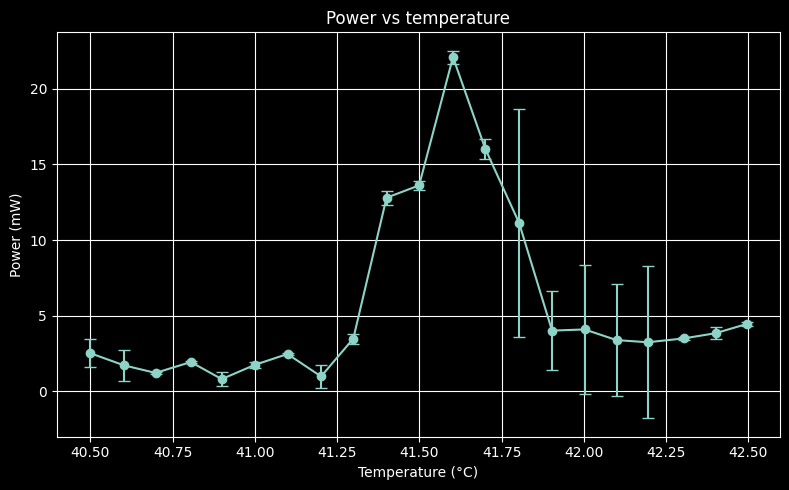

In [33]:
if "df_scan" not in globals() or len(df_scan) == 0:
    print("No points acquired.")
else:
    plt.figure(figsize=(8, 5))
    plt.errorbar(
        df_scan["temperature_measured_C"],
        df_scan["mean_power"] * 1e3,
        yerr=df_scan["std_power"] * 1e3,
        fmt="o-",
        capsize=4,
    )
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Power (mW)")
    plt.title("Power vs temperature")
    plt.grid(True)
    plt.tight_layout()
    plt.show()